# 17 · Gaussian processes and stationary time series

A Gaussian process is specified by its mean and covariance function; the covariance decides how smooth the
paths are, how far correlation reaches, and how fast we can simulate. This notebook samples processes by
Cholesky factorisation and by circulant embedding with the FFT, simulates fractional Brownian motion with
long memory, conditions a GP on data (kriging), and then turns to discrete time: ARMA models, their
autocorrelations and spectra, and how to identify and check them from data.

**What you will learn**
- relate a covariance function to the smoothness of paths
- simulate stationary processes by Cholesky and by circulant embedding
- condition a Gaussian process on data
- identify, fit and check ARMA models

**Before you start:** notebooks 02 and 15; linear algebra  ·  **Time:** about 90 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from engstoch import gaussian as gp, timeseries as ts
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Covariance functions and sample paths

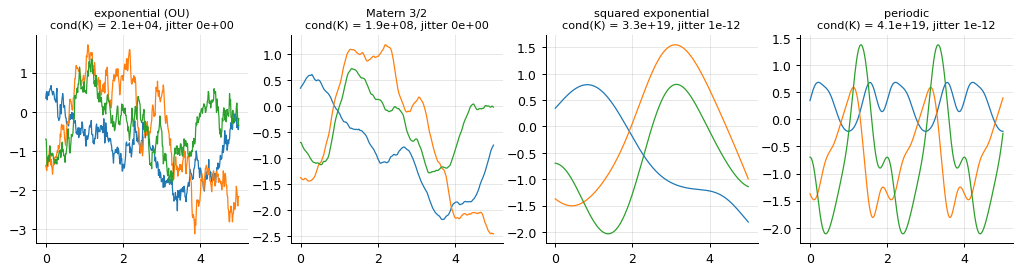

In [2]:
t = np.linspace(0, 5, 400)
fig, ax = plt.subplots(1, 4, figsize=(14, 3))
for axi, (name, k, kw) in zip(ax, (("exponential (OU)", gp.exponential, {"ell": 1.0}), ("Matern 3/2", gp.matern32, {"ell": 1.0}), ("squared exponential", gp.squared_exponential, {"ell": 1.0}), ("periodic", gp.periodic, {"ell": 1.0, "period": 2.0}))):
    s = gp.sample_cholesky(k, t, 3, R(1), **kw)
    axi.plot(t, s["X"].T, lw=1); axi.set_title(f"{name}\ncond(K) = {s['cond']:.1e}, jitter {s['jitter']:.0e}", fontsize=9)
plt.show()

The behaviour of the covariance at the origin sets the roughness: the exponential kernel's kink gives
continuous, nowhere differentiable paths (it is the OU process); Matérn 3/2 is once differentiable; the
squared exponential is infinitely smooth - and its covariance matrices are so ill-conditioned (eigenvalues
decaying faster than exponentially) that Cholesky needs a small "jitter" on the diagonal to run at all.

## Fast simulation by circulant embedding

In [3]:
rows = []
for n in (250, 500, 1000, 2000):
    tt = np.arange(n) * 0.01
    t0 = time.perf_counter(); gp.sample_cholesky(gp.matern32, tt, 1, R(2), ell=1.0); tc = time.perf_counter() - t0
    acov = gp.matern32(0, np.arange(n) * 0.01, ell=1.0)
    try:
        t0 = time.perf_counter(); gp.circulant_embedding(acov, 2, R(3)); te = time.perf_counter() - t0; ok = "yes"
    except ValueError:
        te, ok = np.nan, "needs padding"
    rows.append((n, tc * 1000, te * 1000, ok))
print(pd.DataFrame(rows, columns=["grid points", "Cholesky (ms)", "circulant embedding (ms)", "minimal embedding valid"]).to_string(index=False, float_format="%.1f"))
x = gp.circulant_embedding(gp.exponential(0, np.arange(2048) * 0.01, ell=0.5), 2000, R(4))["X"]
print("exponential kernel, sample covariance at lags 0, 25, 50:", np.round(np.cov(x[:, [0, 25, 50]].T)[0], 3), " theory", np.round(gp.exponential(0, np.array([0, 25, 50]) * 0.01, ell=0.5), 3))

 grid points  Cholesky (ms)  circulant embedding (ms) minimal embedding valid
         250            6.2                       NaN           needs padding
         500           34.4                       NaN           needs padding
        1000          303.6                       0.5                     yes
        2000         2555.3                       1.3                     yes


exponential kernel, sample covariance at lags 0, 25, 50: [1.008 0.614 0.362]  theory [1.    0.607 0.368]


On a regular grid the covariance matrix of a stationary process is Toeplitz; embedding it in a circulant matrix
twice as large diagonalises it by the FFT, so exact samples cost O(n log n) instead of Cholesky's O(n³). The
embedding must be non-negative definite - always true for the exponential kernel, true for Matérn 3/2 once the
window is long compared with the correlation length, and false for smooth kernels on short windows, where one
pads the grid.

## Long memory: fractional Brownian motion

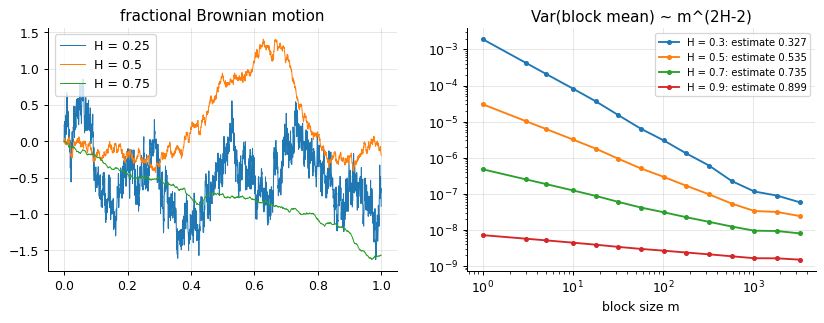

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for H in (0.25, 0.5, 0.75):
    B = gp.fbm_davies_harte(2048, H, 1.0, 1, R(int(100 * H)))[0]
    ax[0].plot(np.linspace(0, 1, 2049), B, lw=0.8, label=f"H = {H}")
ax[0].legend(); ax[0].set_title("fractional Brownian motion")
for H in (0.3, 0.5, 0.7, 0.9):
    est = gp.hurst_aggregated_variance(np.diff(gp.fbm_davies_harte(2**15, H, 1.0, 1, R(7))[0]))
    ax[1].loglog(est["block_sizes"], est["variances"], "o-", ms=3, label=f"H = {H}: estimate {est['H']:.3f}")
ax[1].legend(fontsize=8); ax[1].set_xlabel("block size m"); ax[1].set_title("Var(block mean) ~ m^(2H-2)"); plt.show()

Fractional Brownian motion has Var(B_t) = t^{2H}; its increments (fractional Gaussian noise) are negatively
correlated for H < ½ and positively correlated with a non-summable, power-law autocovariance for H > ½ - long
memory, as in river flows (Hurst's original data), network traffic and volatility. The Davies-Harte method is
circulant embedding of the increments, always valid for fGn. The variance of block means decays like
m^{2H−2} rather than m⁻¹, which is exactly what makes long-memory data hard: averages converge slowly.

## Conditioning on data: Gaussian-process regression

ell = 0.3: log marginal likelihood -10.98
ell = 0.6: log marginal likelihood -8.15
ell = 1.0: log marginal likelihood -7.26
ell = 2.0: log marginal likelihood -18.74
ell = 4.0: log marginal likelihood -91.39


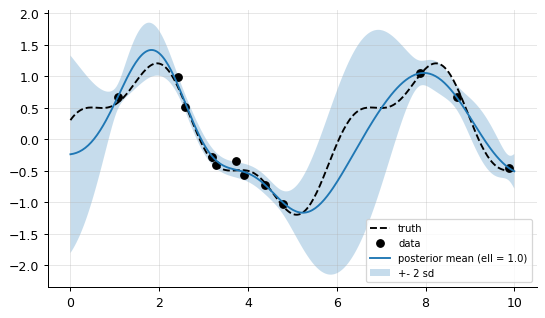

In [5]:
rng = R(8)
x_obs = np.sort(rng.random(12) * 10)
f_true = lambda x: np.sin(x) + 0.3 * np.cos(3 * x)
y_obs = f_true(x_obs) + 0.1 * rng.standard_normal(12)
xs = np.linspace(0, 10, 300)
best = max(((ell, gp.condition(gp.squared_exponential, x_obs, y_obs, xs, noise_var=0.01, ell=ell)) for ell in (0.3, 0.6, 1.0, 2.0, 4.0)), key=lambda p: p[1]["log_marginal_likelihood"])
for ell in (0.3, 0.6, 1.0, 2.0, 4.0):
    print(f"ell = {ell}: log marginal likelihood {gp.condition(gp.squared_exponential, x_obs, y_obs, xs, noise_var=0.01, ell=ell)['log_marginal_likelihood']:.2f}")
post = best[1]
plt.plot(xs, f_true(xs), "k--", label="truth"); plt.plot(x_obs, y_obs, "ko", label="data")
plt.plot(xs, post["mean"], label=f"posterior mean (ell = {best[0]})"); plt.fill_between(xs, post["mean"] - 2 * post["std"], post["mean"] + 2 * post["std"], alpha=0.25, label="+- 2 sd")
plt.legend(fontsize=8); plt.show()

Conditioning a Gaussian vector on some of its coordinates is linear algebra: the posterior mean is a weighted
sum of the observations, the posterior variance shrinks near the data and returns to the prior far from it.
The marginal likelihood of the data - available in closed form - chooses the kernel's length scale; this is
kriging in geostatistics and GP regression in machine learning.

## ARMA models: identification, estimation and checking

causal: True, invertible: True


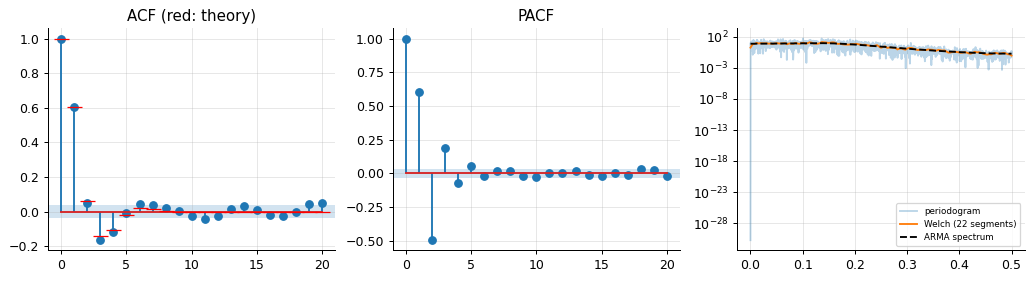

AIC picks an AR(5) approximation; residual Ljung-Box (20 lags): p = 0.511
an AR(2) is too short: residual Ljung-Box p = 4.71e-19


In [6]:
phi, theta = [0.6, -0.3], [0.4]
x = ts.simulate_arma(phi, theta, 3000, R(9))
print(f"causal: {ts.is_causal(phi)}, invertible: {ts.is_invertible(theta)}")
fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
lags = np.arange(21)
ax[0].stem(lags, ts.sample_acf(x, 20)); ax[0].plot(lags, ts.arma_acf(phi, theta, 20), "r_", ms=12); ax[0].axhspan(-ts.acf_bands(3000), ts.acf_bands(3000), alpha=0.2); ax[0].set_title("ACF (red: theory)")
ax[1].stem(lags, ts.sample_pacf(x, 20)); ax[1].axhspan(-ts.acf_bands(3000), ts.acf_bands(3000), alpha=0.2); ax[1].set_title("PACF")
f = np.linspace(0, 0.5, 400)
ax[2].semilogy(ts.periodogram(x)["f"], ts.periodogram(x)["psd"], alpha=0.3, label="periodogram"); w = ts.welch(x, 256)
ax[2].semilogy(w["f"], w["psd"], label=f"Welch ({w['segments']} segments)"); ax[2].semilogy(f, ts.arma_spectrum(phi, theta, f), "k--", label="ARMA spectrum"); ax[2].legend(fontsize=7); plt.show()
sel = ts.select_ar_order(x, 10)
fit = ts.ar_least_squares(x[10 - sel["p"]:], sel["p"])
print(f"AIC picks an AR({sel['p']}) approximation; residual Ljung-Box (20 lags): p = {ts.ljung_box(fit['residuals'], 20, sel['p'])['p_value']:.3f}")
ar2 = ts.ar_least_squares(x, 2)
print(f"an AR(2) is too short: residual Ljung-Box p = {ts.ljung_box(ar2['residuals'], 20, 2)['p_value']:.2e}")

The ACF of an ARMA(2, 1) decays as a damped oscillation; the PACF of a pure AR(p) would cut off after lag p,
but the MA part makes it tail off too - so a finite AR needs several lags to approximate it, and AIC picks the
order. The residual check is the essential last step: an AR(2) leaves autocorrelation that the Ljung-Box test
detects at once. The raw periodogram is unbiased but its variance does not fall with n; Welch's averaging of
segment periodograms makes it consistent at the price of frequency resolution.

## Inside the algorithm: the Durbin-Levinson recursion

In [7]:
gam = ts.arma_acov([0.6, -0.3], [], 3)
phi1 = gam[1] / gam[0]; v1 = gam[0] * (1 - phi1**2)
phi22 = (gam[2] - phi1 * gam[1]) / v1
phi21 = phi1 - phi22 * phi1
print(f"order 2 by hand: ({phi21:.6f}, {phi22:.6f}); library: {ts.durbin_levinson(gam)['phi'][2, 1:3].round(6)}")

order 2 by hand: (0.600000, -0.300000); library: [ 0.6 -0.3]


## Exercises
1. Sample a Matern 5/2 process on 2^14 points of [0, 100] by circulant embedding (pad if needed) and estimate its variogram; compare with the theoretical one.
2. Fit AR models to the log-returns of `prices.csv` and to their squares. Are the returns uncorrelated (Ljung-Box)? Are the squared returns? What does that say about the regime change?
3. **Implement it yourself:** write circulant embedding for a stationary covariance from scratch (FFT of the first row, check of the eigenvalues, complex white noise) and check the sample covariance of 10^4 paths.